In [27]:
from umap import UMAP
from sklearn.manifold import TSNE, MDS

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from zadu.measures import (
    class_aware_trustworthiness_continuity,
    label_trustworthiness_and_continuity
)

In [28]:
dist_mat = np.load('dist_mat.npy')
dist_mat_euc = np.load('dist_mat_euc.npy')
labels = np.load('ship-types.npy')

In [29]:
dist_mat_euc

array([[0.        , 6.22811302, 7.08787204, ..., 8.65669726, 5.58441039,
        8.41783634],
       [6.22811302, 0.        , 6.21732856, ..., 4.51181799, 1.68797   ,
        3.96210983],
       [7.08787204, 6.21732856, 0.        , ..., 6.49430575, 6.06260328,
        7.86135978],
       ...,
       [8.65669726, 4.51181799, 6.49430575, ..., 0.        , 5.19170288,
        2.71535485],
       [5.58441039, 1.68797   , 6.06260328, ..., 5.19170288, 0.        ,
        4.69036737],
       [8.41783634, 3.96210983, 7.86135978, ..., 2.71535485, 4.69036737,
        0.        ]], shape=(750, 750))

(750,) (750,)
(750,) (750,)
(750,) (750,)
(750,) (750,)


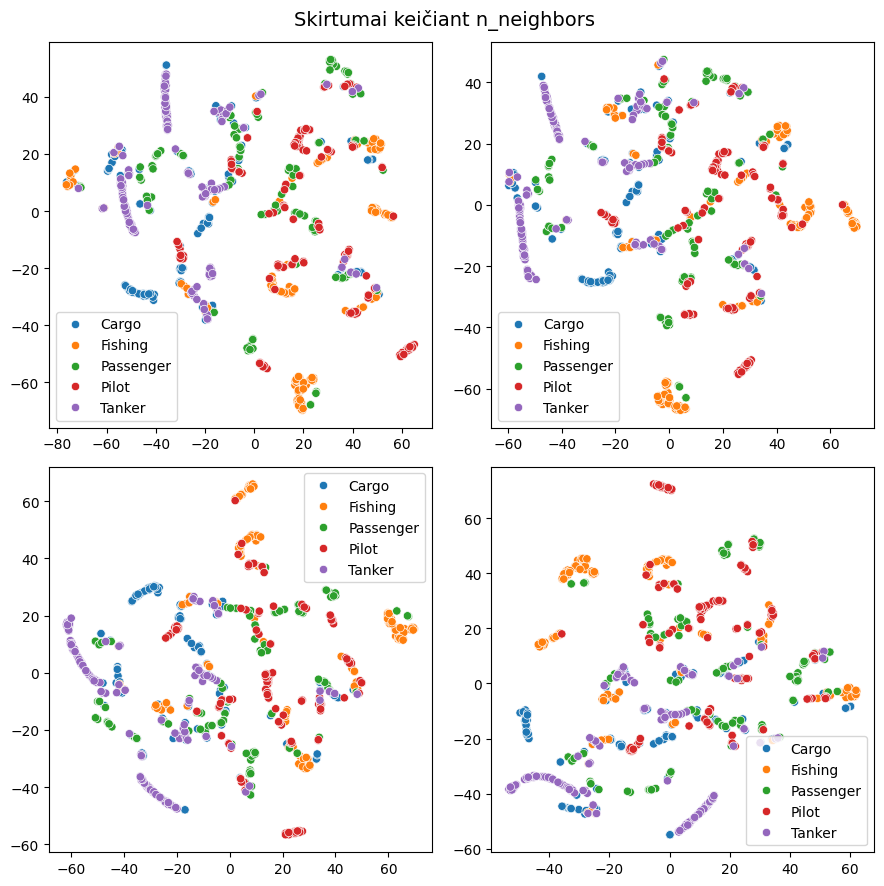

## MDS tyrimas

## t-SNE tyrimas

In [31]:
def plot_tsne(data, perplexity=0.1, early_exaggeration=100, ax=None):
    embeddings = TSNE(perplexity=perplexity, early_exaggeration=early_exaggeration)\
        .fit_transform(data)
    
    if ax is None:
        ax = plt.gca()

    print(embeddings[:, 0].shape, embeddings[:, 1].shape)
    sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], ax=ax, hue=labels) #, s=25, alpha=0.8, hue=labels, palette='bright', ax=ax)

(750,) (750,)
(750,) (750,)
(750,) (750,)
(750,) (750,)


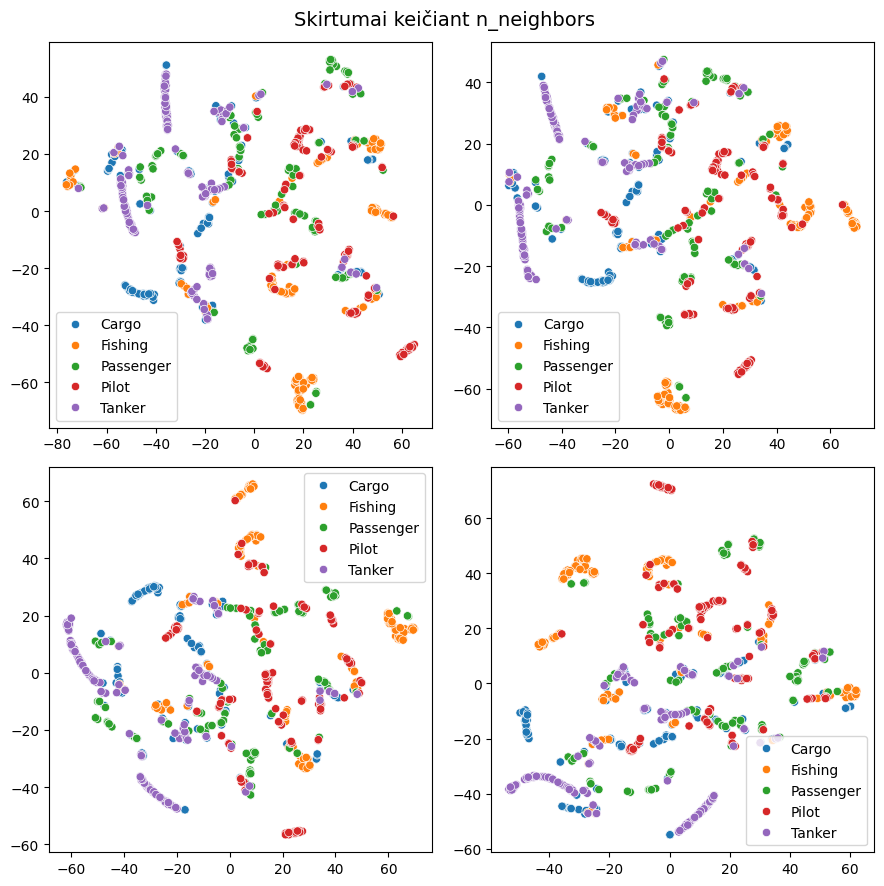

In [35]:
perplexity = [0.01, 1, 10, 100]
early_exaggeration = [1.0, 10.0, 50.0, 100.0]

fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()
fig.suptitle('Skirtumai keičiant n_neighbors', fontsize=14)

for i, n in enumerate(early_exaggeration):
    plot_tsne(data=dist_mat_euc, perplexity=10, early_exaggeration=n, ax=axs[i])

plt.tight_layout()
plt.show()

## UMAP tyrimas

In [36]:
def plot_umap(data, n_neighbors=20, min_dist=0.01, ax=None, var='n_neighbors'):
    embeddings = UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric='precomputed', random_state=1).fit_transform(data)
    
    if ax is None:
        ax = plt.gca()

    sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], s=25, alpha=0.8, hue=labels, palette='bright', ax=ax)

    ax.set_title(f"{var}={locals()[var]}")

/home/lukas/Dokumentai/studijos/ais-duomenu-vizualizavimas/venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/lukas/Dokumentai/studijos/ais-duomenu-vizualizavimas/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lukas/Dokumentai/studijos/ais-duomenu-vizualizavimas/venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/lukas/Dokumentai/studijos/ais-duomenu-vizualizavimas/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lukas/Dokumentai/studijos/ai

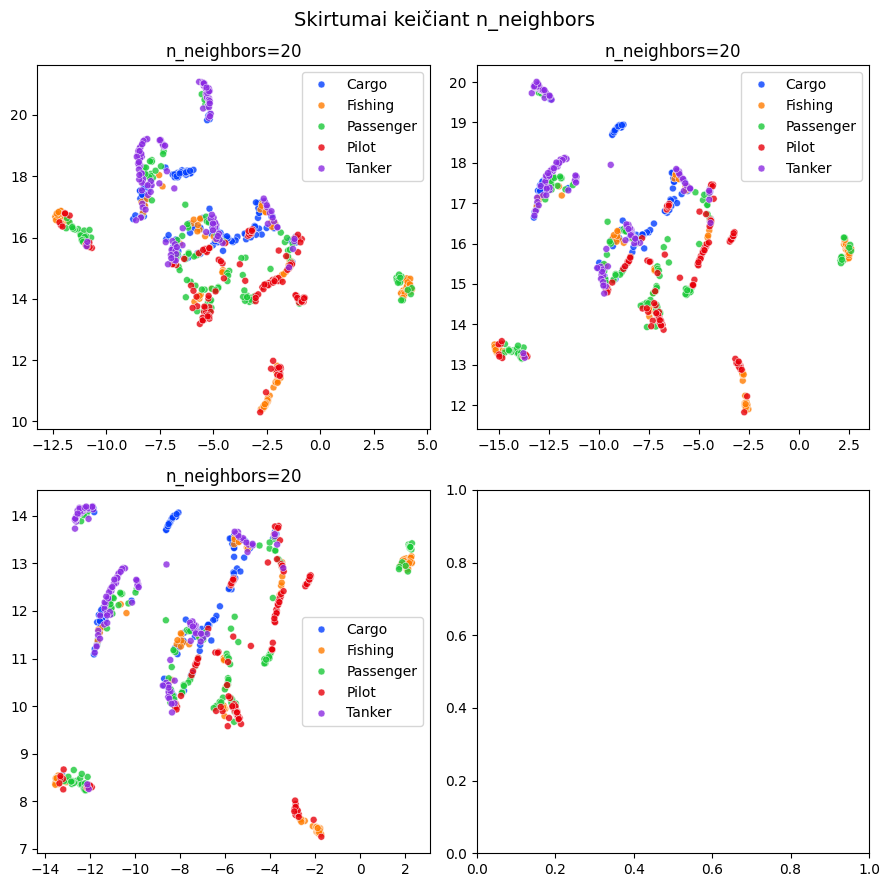

In [37]:
min_distances = [0.1, 0.001, 0.00001]
fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()
fig.suptitle('Skirtumai keičiant n_neighbors', fontsize=14)

for i, n in enumerate(min_distances):
    plot_umap(data=dist_mat, min_dist=n, ax=axs[i])

plt.tight_layout()
plt.show()

In [ ]:
class_aware_trustworthiness_continuity.measure(
    
)

TypeError: measure() missing 3 required positional arguments: 'orig', 'emb', and 'label'